In [72]:
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import pandas as pd 
import matplotlib.pyplot as plt
import os

In [73]:
file_path=os.path.expanduser("~/AI_Engineer/04_Data_Vault/Data_Projects/Medical_Insurance/medical_insurance.csv")

In [74]:
df=pd.read_csv(file_path)

In [75]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [76]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [77]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB
None


In [78]:
df_encoded=pd.get_dummies(df,drop_first=True)
X=df_encoded.drop(['charges'],axis=1)
y=df_encoded['charges']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"the counter of training data is : {X_train.shape[0]}")
print(f"the counter of testing data is :  {X_test.shape[0]}")

the counter of training data is : 2217
the counter of testing data is :  555


In [79]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(f"this is the first part of this operater:\n{X_train_scaled[0]}")

this is the first part of this operater:
[-1.3144233   1.00536512 -0.91183384  0.97902021 -0.51447945 -0.56606433
  1.63790239 -0.5716209 ]


In [80]:
#compute cost using loop:
#def compute_cost(X,y,w,b):
#    m,n=X.shape
#    loss=0
#    for i in range(m):
#        f_wb=0
#        for j in range(n):
#            f_wb+=X[i,j]*w[j]
#        f_wb+b
#        loss+=(f_wb-y[i])**2
#    return 1/(2*m)*loss
#-----------------------------------------------------------------------------------------------------------------------
#-----------------------------------------------------------------------------------------------------------------------
#compute cost using vectorization:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    f_wb=np.dot(X,w)+b
    loss=np.sum(np.power((f_wb-y),2))
    return loss/(2*m)

In [81]:
#compute gradient using loop:
#def compute_gradient(X,y,w,b):
#    m,n=X.shape
#    dj_w=np.zeros((n,1))
#    dj_b=0.
#    error=0
#    for i in range(m):
#        f_wb=0
#        for j in range(n):
#            f_wb+=w[j]*X[i,j]
#        f_wb+=b
#        error=f_wb-y[i]
#        for j in range(n):
#            dj_w[j]+=error*X[i,j]
#        dj_b+=error 
#    dj_w=(1/m)*dj_w
#    dj_b=(1/m)*dj_b
#    return dj_w,dj_b

In [82]:
#compute gradient using vectorzation 
def compute_gradient(X,y,w,b):
    m=X.shape[0]
    f_wb=np.dot(X,w)+b
    err=f_wb-y
    dj_w=(1/m)*np.dot(X.T,err)
    dj_b=(1/m)*np.sum(err)
    return dj_w,dj_b

In [83]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    w = w_in
    b = b_in
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i:4}: Cost {cost:8.4f}")
    return w, b, cost_history

In [113]:
alpha = 0.01
iterations = 10000
n = X_train_scaled.shape[1]
w_initial = np.zeros((n, 1))
b_initial = 0.
y_train_vec = y_train.values.reshape(-1, 1)
w_final, b_final, J_history = gradient_descent(X_train_scaled, y_train_vec, w_initial, b_initial, alpha, iterations)
print(f"{'-' * 64}\n w = \n{w_final.flatten()}")
print(f"{'-' * 64}\n b = {b_final}")

Iteration    0: Cost 159544604.7912
Iteration  100: Cost 37186430.7269
Iteration  200: Cost 20690655.6366
Iteration  300: Cost 18391176.5250
Iteration  400: Cost 18060150.9759
Iteration  500: Cost 18009402.3136
Iteration  600: Cost 18000271.6722
Iteration  700: Cost 17997989.9610
Iteration  800: Cost 17997148.7860
Iteration  900: Cost 17996753.8467
Iteration 1000: Cost 17996550.0862
Iteration 1100: Cost 17996441.7955
Iteration 1200: Cost 17996383.7372
Iteration 1300: Cost 17996352.5301
Iteration 1400: Cost 17996335.7431
Iteration 1500: Cost 17996326.7108
Iteration 1600: Cost 17996321.8507
Iteration 1700: Cost 17996319.2355
Iteration 1800: Cost 17996317.8282
Iteration 1900: Cost 17996317.0710
Iteration 2000: Cost 17996316.6635
Iteration 2100: Cost 17996316.4442
Iteration 2200: Cost 17996316.3262
Iteration 2300: Cost 17996316.2627
Iteration 2400: Cost 17996316.2286
Iteration 2500: Cost 17996316.2102
Iteration 2600: Cost 17996316.2003
Iteration 2700: Cost 17996316.1950
Iteration 2800: Cos

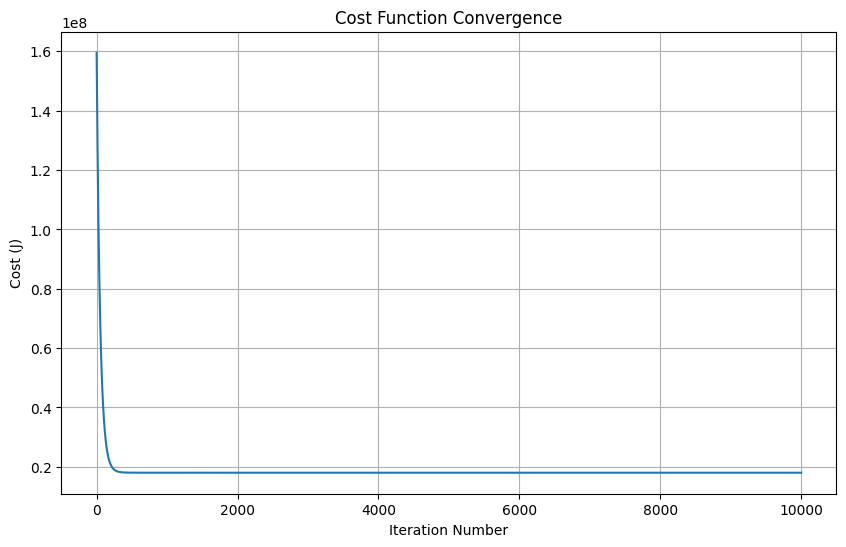

In [114]:
plt.figure(figsize=(10,6))
plt.plot(J_history)
plt.title("Cost Function Convergence")
plt.xlabel("Iteration Number")
plt.ylabel("Cost (J)")
plt.grid(True)
plt.show()

In [118]:
y_prediction = np.dot(X_test_scaled, w_final) + b_final
print("predicted Price   | Actual Price")
print("-" * 25)
for i in range(10):
    print(f"{y_prediction[i][0]:.2f}              |    {y_test.values[i]:.2f}")
score = r2_score(y_test, y_prediction)
print(f"دقة النموذج هي: %{score*100:.2f}")

predicted Price   | Actual Price
-------------------------
10382.20              |    8988.16
36850.70              |    28101.33
9010.64              |    12032.33
5910.23              |    1682.60
6661.47              |    3393.36
34046.51              |    24106.91
5625.02              |    4746.34
38993.95              |    47269.85
11655.91              |    8556.91
3366.19              |    2639.04
دقة النموذج هي: %73.98


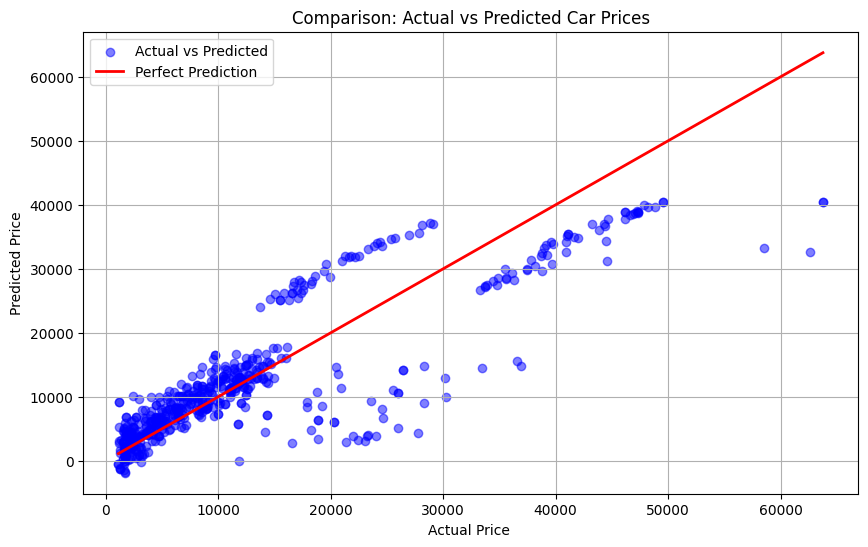

In [116]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_prediction, color='blue', alpha=0.5, label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ')
plt.ylabel('Predicted Price')
plt.title('Comparison: Actual vs Predicted Car Prices')
plt.legend()
plt.grid(True)
plt.show()